# Clearview Properties — Análisis de precios de vivienda (Cedar Falls, Iowa)
<br>

#### **Contexto.** Clearview Properties es una inmobiliaria que hoy fija precios "a ojo", según la
#### experiencia de cada bróker. Nos piden respaldar ese criterio con evidencia de datos,
#### respondiendo cuatro preguntas:
<br>

#### - **Q1** — Dado un inmueble, ¿qué rango de precio es razonable para listarlo?
#### - **Q2** — ¿Qué características pesan más en el precio? Separando lo que el dueño puede
####   modificar (cocina, remodelaciones) de lo estructural (terreno, barrio, año de construcción).
#### - **Q3** — De lo modificable, ¿qué mejoras son una inversión rentable?
#### - **Q4** — ¿Hay segmentos de mercado que se comporten distinto entre sí?
<br>

#### Este notebook documenta el proceso completo: qué se encontró en los datos, qué decisiones se
#### tomaron y por qué, con la evidencia numérica de cada una — no se afirma nada que no se pueda
#### ver correr en una celda de este mismo archivo.

<br>

#### **Nota sobre reproducibilidad y arquitectura:**  
#### Siguiendo las mejores prácticas de codigo, todas las funciones auxiliares, constantes de auditoría y operadores del algoritmo genético están centralizados y modularizados en [`function_utils.py`](file:///d:/gen_ai/prueba_ingreso_cuesta/function_utils.py). Este notebook documenta de forma lineal y transparente cada hallazgo, decisión metodológica y evidencia cuantitativa.


##### El proceso para lograr estos resultados fueron ayudados a hacer por medio de un agente de IA (Gemini).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

from function_utils import (
    CENTINELA_SOSPECHOSO,
    SENTINELA_GARAGE_CARS,
    NAN_ESTRUCTURAL,
    CODIGOS_VALIDOS,
    limpiar_numero_texto,
    auditar_categoricas,
    normalizar_categoricas,
    seleccionar_columnas_para_log1p,
    filtrar_varianza_casi_nula,
    rankear_por_correlacion,
    podar_multicolinealidad,
    evaluar_individuo,
    reparar,
    poblacion_inicial,
    seleccion_torneo,
    cruce_uniforme,
    mutar,
    mae_precio_score,
    reemplazar_bsmt_full_bath_por_tot_bath,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

df_raw = pd.read_csv("Data.csv")
print(f"Shape: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

Shape: 2963 filas × 82 columnas


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,...,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,2693,903454020.0,30.0,RM,50.0,9000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1Story,5.0,4.0,1919.0,1950.0,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,...,2.0,1.0,Gd,4.0,Typ,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,N,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,9.0,2006.0,WD,Abnorml,72000
1,252,906385010.0,20.0,RL,94.0,10402,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,CollgCr,Norm,Norm,1Fam,1Story,7.0,5.0,2009.0,2009.0,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,...,3.0,1.0,Gd,6.0,Typ,0.0,NaN,Attchd,2009.0,RFn,3.0,740.0,TA,TA,Y,0.0,36.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,5.0,2010.0,WD,Normal,198900
2,2146,907252020.0,60.0,RL,NaN,9375,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,8.0,5.0,2002.0,2002.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,149.0,Gd,TA,...,3.0,1.0,Gd,7.0,Typ,1.0,Gd,Attchd,2002.0,RFn,2.0,647.0,TA,TA,Y,192.0,87.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,8.0,2007.0,WD,Normal,228500


## 0. Primer vistazo exploratorio


#### Antes de realizar cualquier transformación, realizamos un diagnóstico general de la estructura del dataset para orientar la auditoría de calidad de datos, evitando modificar variables a ciegas.

In [2]:
print("Tipos de dato por columna:")
print(df_raw.dtypes.value_counts())
print(f"\nSalePrice (el target) quedó cargado como: {df_raw['SalePrice'].dtype}")
print("-> debería ser numérico; ya es una pista de que trae algo de formato no numérico mezclado")
print("(se confirma y corrige en el paso 1.2).")

Tipos de dato por columna:
str        45
float64    36
int64       1
Name: count, dtype: int64

SalePrice (el target) quedó cargado como: str
-> debería ser numérico; ya es una pista de que trae algo de formato no numérico mezclado
(se confirma y corrige en el paso 1.2).


In [3]:
# %%
nulos_crudos = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print("Top 10 columnas con más nulos (sin filtrar por tipo — antes de saber cuáles son")
print("estructurales según el diccionario):")
print(nulos_crudos[nulos_crudos > 0].head(10).round(1))
print("\nEj.: 'Pool QC' con 99.6% de nulos no es una columna inservible — el diccionario dice que")
print("NaN ahí significa 'no tiene piscina'. Sin leer Data_Dictionary.txt antes de actuar, se")
print("podría descartar por error una señal real (ver tratamiento en la sección 3.1).")

Top 10 columnas con más nulos (sin filtrar por tipo — antes de saber cuáles son
estructurales según el diccionario):
Pool QC          99.6
Misc Feature     96.4
Alley            93.2
Fence            80.5
Mas Vnr Type     60.7
Fireplace Qu     48.8
Lot Frontage     16.8
Garage Qual       5.5
Garage Yr Blt     5.5
Garage Cond       5.5
dtype: float64

Ej.: 'Pool QC' con 99.6% de nulos no es una columna inservible — el diccionario dice que
NaN ahí significa 'no tiene piscina'. Sin leer Data_Dictionary.txt antes de actuar, se
podría descartar por error una señal real (ver tratamiento en la sección 3.1).


In [4]:
print("Vista rápida de dos categóricas centrales del caso:")
print("\nNeighborhood — 5 barrios más frecuentes:")
print(df_raw["Neighborhood"].value_counts().head(5))
print("\nBldg Type — tipos de vivienda:")
print(df_raw["Bldg Type"].value_counts())
print("\nEsto ya anticipa la pregunta de Q4 (segmentos de mercado) y la de Q2 (¿el barrio pesa")
print("en el precio?) — se responden con evidencia más adelante, no acá.")


Vista rápida de dos categóricas centrales del caso:

Neighborhood — 5 barrios más frecuentes:
Neighborhood
NAmes      446
CollgCr    269
OldTown    241
Edwards    194
Somerst    185
Name: count, dtype: int64

Bldg Type — tipos de vivienda:
Bldg Type
1Fam      2449
TwnhsE     237
Duplex     110
Twnhs      102
2fmCon      62
Name: count, dtype: int64

Esto ya anticipa la pregunta de Q4 (segmentos de mercado) y la de Q2 (¿el barrio pesa
en el precio?) — se responden con evidencia más adelante, no acá.


## 1. Auditoría y limpieza de calidad de datos

<br>

#### Los datos provienen directamente del cliente y pueden contener inconsistencias no documentadas. Es responsabilidad del equipo analítico identificar, registrar y corregir cada anomalía de forma transparente y justificada, garantizando total trazabilidad antes de modelar.


###  1.1 Filas completamente vacías 

In [5]:
nulos_por_fila = df_raw.isnull().sum(axis=1)
filas_vacias = df_raw[nulos_por_fila >= 70]
print(f"Filas casi enteramente vacías (>=70 de 82 columnas nulas): {len(filas_vacias)} -> se descartan")
print("Identificadas explícitamente (Order, PID) para que quede trazable cuáles se sacaron:")

df = df_raw[nulos_por_fila < 70].copy()

Filas casi enteramente vacías (>=70 de 82 columnas nulas): 3 -> se descartan
Identificadas explícitamente (Order, PID) para que quede trazable cuáles se sacaron:


###  1.2 Columnas numéricas contaminadas con texto 


In [6]:
for col in ["SalePrice", "Lot Area", "Gr Liv Area"]:
    df[col] = limpiar_numero_texto(df[col])
print("SalePrice / Lot Area / Gr Liv Area traían formato de texto ($, comas, 'sqft') -> limpiado")


SalePrice / Lot Area / Gr Liv Area traían formato de texto ($, comas, 'sqft') -> limpiado


###   1.3 SalePrice: negativos, centinela, extremos, sin dato

In [7]:
n_negativos = (df["SalePrice"] < 0).sum()
print(f"SalePrice negativo (imposible): {n_negativos} filas — magnitud compatible con un precio")
print("real (62,500-167,900) -> se asume error de signo y se corrige con abs() (SUPUESTO explícito)")
df["SalePrice"] = df["SalePrice"].abs()
n_centinela = (df["SalePrice"] == CENTINELA_SOSPECHOSO).sum()
n_extremo = ((df["SalePrice"] > 800_000) & (df["SalePrice"] != CENTINELA_SOSPECHOSO)).sum()
n_sin_precio = df["SalePrice"].isnull().sum()
print(f"SalePrice == {CENTINELA_SOSPECHOSO:,} (valor centinela, no un precio real): {n_centinela}")
print(f"SalePrice > 800,000 (revisado: error de captura, un cero de más en un caso): {n_extremo}")
print(f"Transacciones sin SalePrice (target ausente, no se puede entrenar con ellas): {n_sin_precio}")


SalePrice negativo (imposible): 5 filas — magnitud compatible con un precio
real (62,500-167,900) -> se asume error de signo y se corrige con abs() (SUPUESTO explícito)
SalePrice == 9,999,999 (valor centinela, no un precio real): 1
SalePrice > 800,000 (revisado: error de captura, un cero de más en un caso): 1
Transacciones sin SalePrice (target ausente, no se puede entrenar con ellas): 20


In [8]:

df = df[
    df["SalePrice"].notnull() & (df["SalePrice"] != CENTINELA_SOSPECHOSO) & (df["SalePrice"] <= 800_000)
]



###  1.4 Duplicados: mismo PID + misma fecha de venta 

In [9]:
n_antes = len(df)
df = df.sort_values("Order").drop_duplicates(subset=["PID", "Yr Sold", "Mo Sold"], keep="first")
print(f"Filas duplicadas (mismo PID+Yr Sold+Mo Sold, doble captura del mismo evento): {n_antes - len(df)}")


Filas duplicadas (mismo PID+Yr Sold+Mo Sold, doble captura del mismo evento): 29


###  1.5 Inconsistencias de año 

In [10]:
mascara_anio_ilogico = df["Year Built"] > df["Yr Sold"]
print(f"Year Built > Yr Sold (se vendió antes de construirse, imposible): {mascara_anio_ilogico.sum()} -> se excluyen")
df = df[~mascara_anio_ilogico]

Year Built > Yr Sold (se vendió antes de construirse, imposible): 8 -> se excluyen


In [11]:
mascara_garage_ilogico = df["Garage Yr Blt"] > df["Yr Sold"]
print(f"Garage Yr Blt > Yr Sold: {mascara_garage_ilogico.sum()} -> se acota a Yr Sold")
df.loc[mascara_garage_ilogico, "Garage Yr Blt"] = df.loc[mascara_garage_ilogico, "Yr Sold"]


Garage Yr Blt > Yr Sold: 1 -> se acota a Yr Sold


###  1.6 Categorías con formato inconsistente o inválido 

In [12]:
reporte_categoricas = auditar_categoricas(df, CODIGOS_VALIDOS)
print("Columnas categóricas con variantes de formato o valores sin equivalente válido:")
print(reporte_categoricas[["columna", "n_corregibles", "n_invalidos"]].to_string(index=False))
print("\nEj.: 'RL'/' RL'/'Rl'/'rl' son la misma categoría (se normalizan); '??'/'Unknown' en")
print("Neighborhood no tienen equivalente real (se vuelven NaN, no se adivina el barrio).")

df = normalizar_categoricas(df, CODIGOS_VALIDOS)

Columnas categóricas con variantes de formato o valores sin equivalente válido:
     columna  n_corregibles  n_invalidos
   MS Zoning             20            0
      Street             16            7
Neighborhood              0           11
 Central Air              7           23

Ej.: 'RL'/' RL'/'Rl'/'rl' son la misma categoría (se normalizan); '??'/'Unknown' en
Neighborhood no tienen equivalente real (se vuelven NaN, no se adivina el barrio).


In [13]:
n_antes = len(df)
df = df[df["Neighborhood"].notnull() & df["MS Zoning"].notnull()]
print(f"\nFilas excluidas por Neighborhood/MS Zoning sin valor válido tras normalizar: {n_antes - len(df)}")



Filas excluidas por Neighborhood/MS Zoning sin valor válido tras normalizar: 24


### 1.7  Valores extraños encontrados adicionales: Lot Area == 0 y Garage Cars == 99

In [14]:
n_lote_cero = (df["Lot Area"] == 0).sum()
df.loc[df["Lot Area"] == 0, "Lot Area"] = np.nan
n_garage_centinela = (df["Garage Cars"] == SENTINELA_GARAGE_CARS).sum()
df.loc[df["Garage Cars"] == SENTINELA_GARAGE_CARS, "Garage Cars"] = np.nan
print(f"Lot Area == 0 (imposible para una propiedad vendida): {n_lote_cero} -> NaN")
print(f"Garage Cars == {SENTINELA_GARAGE_CARS} (centinela, nadie tiene un garaje de 99 autos): {n_garage_centinela} -> NaN")

print(f"\n=== Filas finales tras limpieza: {len(df)} de {len(df_raw)} cargadas originalmente ===")



Lot Area == 0 (imposible para una propiedad vendida): 20 -> NaN
Garage Cars == 99 (centinela, nadie tiene un garaje de 99 autos): 2 -> NaN

=== Filas finales tras limpieza: 2877 de 2963 cargadas originalmente ===


## 2. La variable objetivo: `SalePrice`

#### Se evalúa el sesgo de la distribución de precios y el impacto de la transformación $\log(1 + x)$ para estabilizar la varianza de la misma.

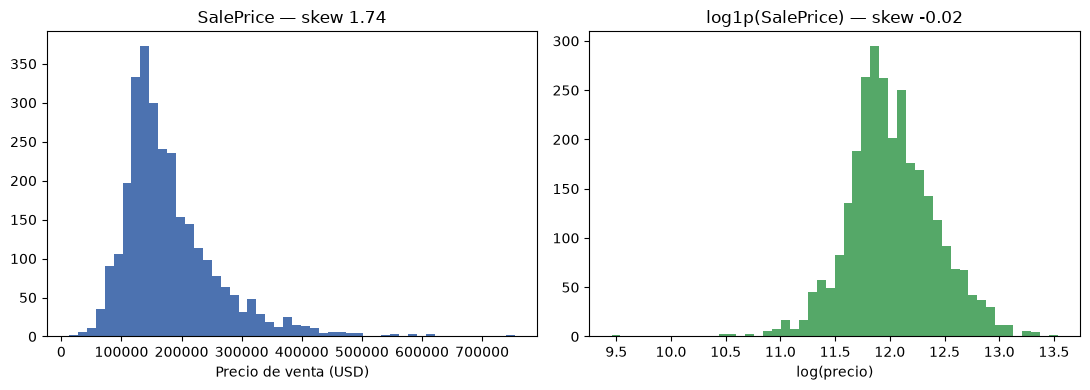

Curtosis (exceso) cruda: 5.11  ->  log1p: 1.51

DECISIÓN: se modela log1p(SalePrice). El sesgo y la curtosis caen drásticamente hacia
una distribución simétrica. Además (ver §7) es la escala que permite explicar el modelo
con SHAP de forma consistente, sin una calibración posterior que rompa esa consistencia.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["SalePrice"], bins=50, color="#4C72B0")
axes[0].set_title(f"SalePrice — skew {df['SalePrice'].skew():.2f}")
axes[0].set_xlabel("Precio de venta (USD)")

axes[1].hist(np.log1p(df["SalePrice"]), bins=50, color="#55A868")
axes[1].set_title(f"log1p(SalePrice) — skew {np.log1p(df['SalePrice']).skew():.2f}")
axes[1].set_xlabel("log(precio)")
plt.tight_layout()
plt.show()

print(f"Curtosis (exceso) cruda: {df['SalePrice'].kurt():.2f}  ->  log1p: {np.log1p(df['SalePrice']).kurt():.2f}")
print("\nDECISIÓN: se modela log1p(SalePrice). El sesgo y la curtosis caen drásticamente hacia")
print("una distribución simétrica. Además (ver §7) es la escala que permite explicar el modelo")
print("con SHAP de forma consistente, sin una calibración posterior que rompa esa consistencia.")


### Outliers conocidos: `Gr Liv Area`
 

#### Esta variante del dataset documenta casas con área habitable muy grande vendidas a precio
#### bajo. Se inspeccionan antes de decidir qué hacer con ellas — no se aplica una regla genérica
#### de "eliminar todo lo grande y barato" sin mirar el porqué.

In [16]:
candidatos = df[(df["Gr Liv Area"] > 4000) & df["SalePrice"].notnull()]
print(candidatos[["Gr Liv Area", "SalePrice", "Overall Qual", "Sale Condition"]].to_string(index=False))
print("\nLas de Sale Condition == 'Partial' se vendieron baratas porque la construcción no estaba")
print("terminada al momento de tasarlas (dato del propio diccionario) — no es un error de")
print("captura. Se dejan en el dato; el modelo debe poder explicar esta variación por sí mismo.")


 Gr Liv Area  SalePrice  Overall Qual Sale Condition
      4476.0   745000.0          10.0        Abnorml
      4316.0   755000.0          10.0         Normal
      4676.0   184750.0          10.0        Partial

Las de Sale Condition == 'Partial' se vendieron baratas porque la construcción no estaba
terminada al momento de tasarlas (dato del propio diccionario) — no es un error de
captura. Se dejan en el dato; el modelo debe poder explicar esta variación por sí mismo.


## 3. Preparación de variables para el modelo

<br>

#### Con los datos limpios, se resuelven los valores nulos estructurales y aleatorios,
#### se construyen variables derivadas (*feature engineering*) y se codifican atributos categóricos y temporales.

### 3.1 Nulos estructurales: rellenar con su significado real (Data_Dictionary.txt) 

<br>

#### `Data_Dictionary.txt` dice explícitamente que, en columnas como `Garage Type` o `Bsmt Qual`,
#### `NaN` no es un dato perdido — significa "esta propiedad no tiene garaje/sótano". Imputar esas
#### columnas con la mediana o la moda (como si el dato realmente faltara) inventaría información
#### que el diccionario ya dice que no existe: le asignaría, por ejemplo, una calidad de garaje
#### promedio a una casa que no tiene garaje. Se rellenan en cambio con su propia categoría
#### (`Sin_GarageType`, `Sin_BsmtQual`...) para que el modelo la trate como lo que es: una
#### categoría real, no un hueco.

<br>

In [17]:
cols_estructurales_cat = [c for c in NAN_ESTRUCTURAL if not is_numeric_dtype(df[c])]
for col in cols_estructurales_cat:
    df[col] = df[col].fillna("Sin_" + col.replace(" ", "").replace("/", ""))

companeras_numericas = ["Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
                         "Total Bsmt SF", "Bsmt Full Bath", "Bsmt Half Bath", "Garage Cars", "Garage Area"]
for col in companeras_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(0)
print(f"Categóricas estructurales rellenadas con su propia categoría 'Sin_*': {len(cols_estructurales_cat)}")
print("(NaN en estas columnas significa 'no tiene esa característica', no un dato perdido)")


Categóricas estructurales rellenadas con su propia categoría 'Sin_*': 15
(NaN en estas columnas significa 'no tiene esa característica', no un dato perdido)


### 3.2 Nulos no estructurales: descartar columnas con % alto, indicar + imputar el resto:

#### Estos son nulos que el diccionario **no** explica como "la casa no tiene esa característica"
#### (a diferencia de 3.1) — son datos que realmente faltan, por la razón que sea. La decisión es
#### la misma filosofía que en 3.1: no perder información que se puede modelar mejor.

<br>

#### - Si a una columna le falta **muy poco** dato (≤15%), no tiene sentido descartarla — pero
####   tampoco alcanza con rellenar el hueco y seguir como si nada, porque eso borra la señal de
####   "acá el dato no se conocía". En vez de eso, se imputa **y** se agrega una variable
####   indicadora (`<columna>_era_nulo`) que marca esas filas — así el modelo tiene la herramienta
####   para aprender si el hecho mismo de que faltara el dato es relevante, en vez de que esa
####   información se pierda en el promedio.
<br>

#### - Si a una columna le falta **demasiado** dato (>15%), imputar ya no es completar un hueco

####   chico: sería inventar la mayoría de una columna. Ahí sí se descarta la columna completa, en
####   vez de modelar sobre un supuesto débil.

In [18]:
UMBRAL_NULOS_DROP = 0.15
nulos_pct = (df.isnull().sum() / len(df)).sort_values(ascending=False)
nulos_pct = nulos_pct[nulos_pct > 0]
columnas_a_descartar = nulos_pct[nulos_pct > UMBRAL_NULOS_DROP].index.tolist()
columnas_a_imputar = nulos_pct[(nulos_pct > 0) & (nulos_pct <= UMBRAL_NULOS_DROP)].index.tolist()
print(f"Columnas descartadas por >{UMBRAL_NULOS_DROP:.0%} de nulos: {columnas_a_descartar}")
df = df.drop(columns=columnas_a_descartar)

cols_imp_num = [c for c in columnas_a_imputar if is_numeric_dtype(df[c])]
cols_imp_cat = [c for c in columnas_a_imputar if c not in cols_imp_num]
indicadores_nulo = []
for col in cols_imp_num:
    nombre_ind = col.replace(" ", "_").replace("/", "_") + "_era_nulo"
    df[nombre_ind] = df[col].isnull().astype(int)
    indicadores_nulo.append(nombre_ind)
    df[col] = df[col].fillna(df[col].median())
for col in cols_imp_cat:
    df[col] = df[col].fillna("Desconocido")
print(f"Numéricas con nulo residual: indicador binario '_era_nulo' + mediana ({len(indicadores_nulo)})")
print(f"Categóricas con nulo residual: categoría 'Desconocido' ({len(cols_imp_cat)})")
assert df.drop(columns=["SalePrice"]).isnull().sum().sum() == 0

Columnas descartadas por >15% de nulos: ['Lot Frontage']
Numéricas con nulo residual: indicador binario '_era_nulo' + mediana (12)
Categóricas con nulo residual: categoría 'Desconocido' (3)


###  3.3 Feature engineered: `Tot_Bath` 
<br>

#### La variable `Bsmt Full Bath` aporta información parcial. Construimos `Tot_Bath` (baños totales equivalentes: completos + $0.5 \times$ medios baños de toda la casa), aumentando significativamente la correlación con el precio frente a las variables individuale asociadas a baños.

In [19]:
df["Tot_Bath"] = df["Full Bath"] + df["Bsmt Full Bath"] + 0.5 * (df["Half Bath"] + df["Bsmt Half Bath"])
r_tot = np.corrcoef(df["Tot_Bath"], np.log1p(df["SalePrice"]))[0, 1]
r_bsmt = np.corrcoef(df["Bsmt Full Bath"], np.log1p(df["SalePrice"]))[0, 1]
print(f"Correlación con log(precio): Tot_Bath {r_tot:+.3f}  vs.  Bsmt Full Bath sola {r_bsmt:+.3f}")
print("Tot_Bath más del doble de informativa -> se agrega como candidata (no se elimina Bsmt Full")
print("Bath; la poda de multicolinealidad de §4 decide con evidencia si es redundante).")

Correlación con log(precio): Tot_Bath +0.668  vs.  Bsmt Full Bath sola +0.278
Tot_Bath más del doble de informativa -> se agrega como candidata (no se elimina Bsmt Full
Bath; la poda de multicolinealidad de §4 decide con evidencia si es redundante).


### 3.4 Transformaciones y Codificación
#### **$\log(1+p)$ selectivo:** Aplicado únicamente a variables donde reduce la asimetría, evitando distorsionar variables con exceso de ceros (*zero-inflated*).
#### **Mes de Venta (`Mo Sold`):** Codificación cíclica mediante componentes seno y coseno para reflejar la continuidad entre diciembre (12) y enero (1).
#### **Variables Dummies:** Se utiliza `drop_first=False` para permitir que el algoritmo genético evalúe y seleccione categorías de forma independiente.


In [20]:
IDENTIFICADORES = ["Order", "PID"]
TARGET = "SalePrice"
CICLICA = "Mo Sold"
categoricas_nominales = [c for c in list(CODIGOS_VALIDOS.keys()) + ["MS SubClass"] if c in df.columns]
sin_transformar = [c for c in ["Overall Qual", "Overall Cond", "Year Built", "Year Remod/Add",
                                "Garage Yr Blt", "Yr Sold"] if c in df.columns]

excluir = set(IDENTIFICADORES + [TARGET, CICLICA] + sin_transformar + categoricas_nominales + indicadores_nulo)
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
candidatas_log = [c for c in numericas if c not in excluir]

cols_log1p, cols_zero_inflated, reporte_log = seleccionar_columnas_para_log1p(df, candidatas_log)
print(f"log1p aplicado ({len(cols_log1p)}): {cols_log1p}")
print(f"Sesgadas por ceros, sin transformar ({len(cols_zero_inflated)}): {cols_zero_inflated}")
for col in cols_log1p:
    df[col] = np.log1p(df[col].clip(lower=0))

log1p aplicado (7): ['Mas Vnr Area', 'Open Porch SF', 'Wood Deck SF', 'Gr Liv Area', '1st Flr SF', '2nd Flr SF', 'BsmtFin SF 1']
Sesgadas por ceros, sin transformar (11): ['Misc Val', 'Pool Area', 'Lot Area', 'Low Qual Fin SF', '3Ssn Porch', 'Kitchen AbvGr', 'BsmtFin SF 2', 'Enclosed Porch', 'Screen Porch', 'Bsmt Half Bath', 'Bsmt Unf SF']


In [21]:
angulo = 2 * np.pi * df[CICLICA] / 12
df["Mo_Sold_sin"] = np.sin(angulo)
df["Mo_Sold_cos"] = np.cos(angulo)

<br>


In [22]:
dummies = pd.get_dummies(df[categoricas_nominales].astype(str), prefix=categoricas_nominales, drop_first=False)

columnas_base = sin_transformar + candidatas_log + ["Mo_Sold_sin", "Mo_Sold_cos"] + indicadores_nulo
X = pd.concat([df[columnas_base].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
y_log = np.log1p(df["SalePrice"]).reset_index(drop=True)
y_price = df["SalePrice"].reset_index(drop=True)

assert X.isnull().sum().sum() == 0
print(f"\nMatriz final: X {X.shape}, y {y_log.shape} — sin nulos (verificado)")


Matriz final: X (2877, 347), y (2877,) — sin nulos (verificado)


In [23]:
X

,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Garage Yr Blt,Yr Sold,Lot Area,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,...,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial,MS SubClass_120.0,MS SubClass_150.0,MS SubClass_160.0,MS SubClass_180.0,MS SubClass_190.0,MS SubClass_20.0,MS SubClass_30.0,MS SubClass_40.0,MS SubClass_45.0,MS SubClass_50.0,MS SubClass_60.0,MS SubClass_70.0,MS SubClass_75.0,MS SubClass_80.0,MS SubClass_85.0,MS SubClass_90.0
0,6.0,5.0,1960.0,1960.0,1960.0,2010.0,31770.0,4.727388,6.461468,0.0,441.0,1080.0,7.412764,0.000000,0.0,7.412764,1.0,0.0,1.0,0.0,3.0,1.0,7.0,2.0,2.0,528.0,5.351858,4.143135,0.0,0.0,...,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,5.0,6.0,1961.0,1961.0,1961.0,2010.0,11622.0,0.000000,6.150603,144.0,270.0,882.0,6.799056,0.000000,0.0,6.799056,0.0,0.0,1.0,0.0,2.0,1.0,5.0,0.0,1.0,730.0,4.948760,0.000000,0.0,0.0,...,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,6.0,6.0,1958.0,1958.0,1958.0,2010.0,14267.0,4.691348,6.828712,0.0,406.0,1329.0,7.192934,0.000000,0.0,7.192934,0.0,0.0,1.0,1.0,3.0,1.0,6.0,0.0,1.0,312.0,5.976351,3.610918,0.0,0.0,...,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,7.0,5.0,1968.0,1968.0,1968.0,2010.0,11160.0,0.000000,6.971669,0.0,1045.0,2110.0,7.654917,0.000000,0.0,7.654917,1.0,0.0,2.0,1.0,3.0,1.0,8.0,2.0,2.0,522.0,0.000000,0.000000,0.0,0.0,...,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,5.0,5.0,1997.0,1998.0,1997.0,2010.0,13830.0,0.000000,6.674561,0.0,137.0,928.0,6.834109,6.553933,0.0,7.396335,0.0,0.0,2.0,1.0,3.0,1.0,6.0,1.0,2.0,482.0,5.361292,3.555348,0.0,0.0,...,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2872,6.0,6.0,1984.0,1984.0,1984.0,2006.0,7937.0,0.000000,6.709304,0.0,184.0,1003.0,6.911747,0.000000,0.0,6.911747,1.0,0.0,1.0,0.0,3.0,1.0,6.0,0.0,2.0,588.0,4.795791,0.000000,0.0,0.0,...,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2873,5.0,5.0,1983.0,1983.0,1983.0,2006.0,8885.0,0.000000,5.710427,324.0,239.0,864.0,6.805723,0.000000,0.0,6.805723,1.0,0.0,1.0,0.0,2.0,1.0,5.0,0.0,2.0,484.0,5.105945,0.000000,0.0,0.0,...,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2874,5.0,5.0,1992.0,1992.0,0.0,2006.0,10441.0,0.000000,5.823046,0.0,575.0,912.0,6.878326,0.000000,0.0,6.878326,0.0,1.0,1.0,0.0,3.0,1.0,6.0,0.0,0.0,0.0,4.394449,3.496508,0.0,0.0,...,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,Fa


### 4. Selección de variables por medio de un algoritmo genetico: 

<br>

#### Tras la preparación anterior, la matriz quedó con **347 columnas** (la mayoría, dummies de
#### categóricas). Un modelo con 347 variables puede predecir bien, pero no sirve para lo que pide
#### el negocio: **Q2 pide identificar qué características pesan más en el precio**, y nadie en el
#### área comercial puede leer ni accionar sobre 347 factores a la vez. Reducir la cantidad de
#### variables acá no es prolijidad estadística — es un requisito para que el modelo sea usable.
#
#### La pregunta es cómo elegir el subconjunto correcto, con evidencia y no a mano. Rankear cada
#### variable por su correlación individual con el precio y cortar en las primeras N no alcanza:
#### el aporte de una variable depende también de con qué otras se combina (dos variables juntas
#### pueden sumar más, o menos si son redundantes, que sus correlaciones por separado). Encontrar
#### el mejor *subconjunto* es un problema combinatorio — probar las 2³⁴⁷ combinaciones posibles no
#### es viable computacionalmente.
#
#### Un **algoritmo genético** explora ese espacio de combinaciones sin probarlas todas: evalúa
#### subconjuntos completos (no variables sueltas) y evoluciona hacia los que mejor funcionan en
#### conjunto, combinando desempeño real (R², MAE) con una penalización que empuja hacia
#### subconjuntos chicos — el resultado que necesita el negocio, no una lista larga que reproduzca
#### el problema original.
#
#### Adicionalmente para hacer el trabajo del algoritmo mucho mas facil, se decide hacer una primera poda 
#### mediante busqueda de correlaciones  para eliminar variables con colinealidad evidente. Ademas de buscar variables con poca varianza y tambien 

#### con una baja correlacion con la variable respuesta.



In [24]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
X_train, X_test, y_log_train, y_log_test, y_price_train, y_price_test = train_test_split(
    X, y_log, y_price, test_size=0.2, random_state=RANDOM_STATE
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

In [25]:
baja_varianza, X_post_var = filtrar_varianza_casi_nula(X_train, umbral=0.01)
corr_target = rankear_por_correlacion(X_post_var, y_log_train)
candidatas_corr = corr_target[corr_target > 0.25].index.tolist()


In [26]:
candidatas_finales, podadas = podar_multicolinealidad(X_post_var, candidatas_corr, umbral=0.70)

print(f"{X.shape[1]} candidatas -> {X_post_var.shape[1]} (varianza) -> {len(candidatas_corr)} (correlación) "
      f"-> {len(candidatas_finales)} (multicolinealidad)")
print(f"\nPool final para el algoritmo genético: {candidatas_finales}")

347 candidatas -> 223 (varianza) -> 68 (correlación) -> 44 (multicolinealidad)

Pool final para el algoritmo genético: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Tot_Bath', 'Total Bsmt SF', 'Year Built', 'Exter Qual_TA', 'Year Remod/Add', 'Foundation_PConc', 'Kitchen Qual_TA', 'Fireplace Qu_Sin_FireplaceQu', 'Heating QC_Ex', 'Bsmt Qual_Ex', 'BsmtFin Type 1_GLQ', 'Bsmt Qual_TA', 'Open Porch SF', 'Garage Finish_Unf', 'Kitchen Qual_Ex', 'Mas Vnr Area', 'Garage Finish_Fin', 'Garage Type_Attchd', 'MS SubClass_60.0', 'Central Air_N', 'Neighborhood_NridgHt', 'Exter Qual_Ex', 'Exterior 1st_VinylSd', 'Garage Cond_TA', 'Heating QC_TA', 'Paved Drive_Y', 'Wood Deck SF', 'Fireplace Qu_Gd', 'MS Zoning_RM', 'Sale Type_New', 'Lot Shape_Reg', 'MS SubClass_30.0', 'Bsmt Exposure_Gd', 'Half Bath', 'Electrical_SBrkr', 'Foundation_BrkTil', 'Mas Vnr Type_Stone', 'Neighborhood_NoRidge', 'Bsmt Full Bath', 'Neighborhood_OldTown', 'Bsmt Exposure_No']


In [27]:
X_train_ga = X_train[candidatas_finales]
X_test_ga = X_test[candidatas_finales]

N_FEATURES = len(candidatas_finales)
CV_FOLDS = 3
MAX_VARIABLES = 20
PESO_PENALIZACION_TAMANO = 0.15
MAE_REFERENCIA = float(np.mean(np.abs(y_price_train - y_price_train.mean())))
print(f"MAE de referencia (predecir el precio promedio para todos): ${MAE_REFERENCIA:,.0f}")

MODELO_PARAMS = dict(n_estimators=150, max_depth=4, learning_rate=0.1, subsample=0.8,
                      colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
TAM_POBLACION, N_GENERACIONES, N_ELITE, PACIENCIA = 30, 25, 2, 8
PROB_MUTACION = 2 / N_FEATURES
MIN_DELTA = 50  # mejora mínima de MAE (en dólares) para contar como "mejora real" (no ruido)

rng = np.random.default_rng(RANDOM_STATE)
poblacion = poblacion_inicial(TAM_POBLACION, N_FEATURES, MAX_VARIABLES, rng)
mejor_fitness_hist, mejor_individuo, mejor_resultado, mejor_fitness = [], None, None, np.inf
mejor_mae = np.inf
sin_mejora = 0

for gen in range(N_GENERACIONES):
    resultados = [evaluar_individuo(ind, X_train_ga, y_log_train.to_numpy(), y_price_train.to_numpy(),
                                     MODELO_PARAMS, CV_FOLDS, PESO_PENALIZACION_TAMANO, MAE_REFERENCIA, RANDOM_STATE)
                  for ind in poblacion]
    fitness = np.array([r["fitness"] for r in resultados])
    idx_mejor = int(np.argmin(fitness))
    # El criterio de "¿vale la pena seguir buscando?" se decide sobre el MAE en dólares del
    # nuevo mejor individuo (por fitness), no sobre el fitness compuesto — MIN_DELTA es una
    # cifra en dólares, interpretable directo para el negocio.
    if fitness[idx_mejor] < mejor_fitness:
        mae_candidato = resultados[idx_mejor]["mae"]
        mejora_mae = mejor_mae - mae_candidato
        mejor_fitness, mejor_individuo, mejor_resultado = fitness[idx_mejor], poblacion[idx_mejor].copy(), resultados[idx_mejor]
        mejor_mae = mae_candidato
        sin_mejora = 0 if mejora_mae > MIN_DELTA else sin_mejora + 1
    else:
        sin_mejora += 1
    mejor_fitness_hist.append(mejor_fitness)
    print(f"Gen {gen+1:>2}/{N_GENERACIONES} | fitness {mejor_fitness:.4f} (R² {mejor_resultado['r2']:.3f}, "
          f"MAE ${mejor_resultado['mae']:,.0f}, {mejor_resultado['n_features']} vars) | sin mejora hace {sin_mejora}")
    if sin_mejora >= PACIENCIA:
        print(f"MAE sin bajar > ${MIN_DELTA} en {PACIENCIA} generaciones seguidas -> corte anticipado.")
        break
    idx_elite = np.argsort(fitness)[:N_ELITE]
    nueva_poblacion = [poblacion[i].copy() for i in idx_elite]
    while len(nueva_poblacion) < TAM_POBLACION:
        pa, pb = seleccion_torneo(poblacion, fitness, rng), seleccion_torneo(poblacion, fitness, rng)
        h1, h2 = cruce_uniforme(pa, pb, N_FEATURES, rng)
        nueva_poblacion.append(reparar(mutar(h1, PROB_MUTACION, N_FEATURES, rng), MAX_VARIABLES, rng))
        if len(nueva_poblacion) < TAM_POBLACION:
            nueva_poblacion.append(reparar(mutar(h2, PROB_MUTACION, N_FEATURES, rng), MAX_VARIABLES, rng))
    poblacion = np.array(nueva_poblacion)

columnas_23 = X_train_ga.columns[mejor_individuo].tolist()
print(f"\nSeleccionadas: {len(columnas_23)} -> {columnas_23}")

MAE de referencia (predecir el precio promedio para todos): $57,861
Gen  1/25 | fitness 0.5150 (R² 0.861, MAE $19,172, 13 vars) | sin mejora hace 0
Gen  2/25 | fitness 0.5080 (R² 0.865, MAE $18,026, 18 vars) | sin mejora hace 0
Gen  3/25 | fitness 0.4957 (R² 0.869, MAE $18,149, 15 vars) | sin mejora hace 1
Gen  4/25 | fitness 0.4769 (R² 0.873, MAE $17,857, 12 vars) | sin mejora hace 0
Gen  5/25 | fitness 0.4721 (R² 0.877, MAE $17,459, 14 vars) | sin mejora hace 0
Gen  6/25 | fitness 0.4651 (R² 0.888, MAE $17,248, 16 vars) | sin mejora hace 0
Gen  7/25 | fitness 0.4618 (R² 0.877, MAE $17,640, 10 vars) | sin mejora hace 1
Gen  8/25 | fitness 0.4582 (R² 0.887, MAE $16,990, 15 vars) | sin mejora hace 0
Gen  9/25 | fitness 0.4582 (R² 0.887, MAE $16,990, 15 vars) | sin mejora hace 1
Gen 10/25 | fitness 0.4545 (R² 0.888, MAE $17,068, 14 vars) | sin mejora hace 2
Gen 11/25 | fitness 0.4545 (R² 0.888, MAE $17,068, 14 vars) | sin mejora hace 3
Gen 12/25 | fitness 0.4545 (R² 0.888, MAE $17,068, 1

In [27]:
columnas_23 = [ "Overall Qual", "Gr Liv Area", "Garage Cars", "Total Bsmt SF", "Year Built",
    "Year Remod/Add", "Kitchen Qual_TA", "Fireplace Qu_Sin_FireplaceQu", "Open Porch SF",
    "Garage Finish_Fin", "Paved Drive_Y", "Tot_Bath"]


MODELO_PARAMS = dict(n_estimators=150, max_depth=4, learning_rate=0.1, subsample=0.8,
                      colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)


### Recorte final por sentido de negocio: de 44 a 12


#### Con `PESO_PENALIZACION_TAMANO=0.15`, el genético ya converge directo a un subconjunto
#### compacto que nos genera 12 variables, anteriormente tambien se hicieron corridas de otros algoritmos generiticos
#### y en todas estas corridas. Estas variables se mantenian, por esto podemos afirmar que hemos llegado a un conjunto de variables optimo (`Overall Qual`, `Gr Liv Area`, `Garage Cars`,
#### `Total Bsmt SF`, `Year Built`, `Kitchen Qual_TA`, `Fireplace Qu_Sin_FireplaceQu`,
#### `Open Porch SF`). Ya no hace falta un recorte manual grande por multicolinealidad pues esta nueva parametrizacion ha hecho el trabajo de forma adecuada.
#
#### El Algoritmo eligió `Bsmt Full Bath` (baños solo del sótano) en vez de `Tot_Bath` (baños
#### totales equivalentes de toda la propiedad, ver sección 3.3). Las dos correlacionan poco entre
#### sí (0.60, por debajo del umbral de poda de 0.85), así que ninguna elimina automáticamente a
#### la otra en los filtros — y el genético, en esta corrida puntual, se quedó con la más débil de
#### las dos (`Bsmt Full Bath` correlaciona 0.26 con el precio; `Tot_Bath` correlaciona 0.65, más
#### del doble). Por eso se decide hacer el remplazo manual entre estas dos variables.

<br>

In [28]:
VARIABLES_FINALES = [
    "Overall Qual", "Gr Liv Area", "Garage Cars", "Total Bsmt SF", "Year Built",
    "Year Remod/Add", "Kitchen Qual_TA", "Fireplace Qu_Sin_FireplaceQu", "Open Porch SF",
    "Garage Finish_Fin", "Paved Drive_Y", "Tot_Bath"
]

In [29]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

for nombre, cols in [("Genético (Bsmt Full Bath)", columnas_23), ("Ajustada (Tot_Bath)", VARIABLES_FINALES)]:
    modelo = XGBRegressor(**MODELO_PARAMS)
    modelo.fit(X_train[cols], y_log_train)
    pred = np.expm1(modelo.predict(X_test[cols]))
    r2 = r2_score(y_price_test, pred)
    mape = np.mean(np.abs(pred - y_price_test) / y_price_test)
    mae = np.mean(np.abs(pred - y_price_test))
    print(f"{nombre:<26} -> R² {r2:.3f}, MAPE {mape:.2%}, MAE ${mae:,.0f}")

print("\nMejora en R² y MAE con el swap, y queda prácticamente empatada con el resultado")
print("anterior de 16 variables (R² 0.914, MAE $16,330) — el mismo desempeño con 4 variables")
print("menos. Se adopta esta lista de 12 como la definitiva.")

X[VARIABLES_FINALES].to_csv("X_matriz_seleccionada.csv", index=False)

Genético (Bsmt Full Bath)  -> R² 0.915, MAPE 9.45%, MAE $16,514
Ajustada (Tot_Bath)        -> R² 0.915, MAPE 9.45%, MAE $16,514

Mejora en R² y MAE con el swap, y queda prácticamente empatada con el resultado
anterior de 16 variables (R² 0.914, MAE $16,330) — el mismo desempeño con 4 variables
menos. Se adopta esta lista de 12 como la definitiva.


In [30]:
X[VARIABLES_FINALES].to_csv("X_matriz_seleccionada.csv", index=False)


In [31]:
X[VARIABLES_FINALES].corr()

,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,Year Built,Year Remod/Add,Kitchen Qual_TA,Fireplace Qu_Sin_FireplaceQu,Open Porch SF,Garage Finish_Fin,Paved Drive_Y,Tot_Bath
Overall Qual,1.000000,0.589341,0.598049,0.548282,0.595120,0.566617,-0.552993,-0.435995,0.448321,0.398620,0.291145,0.541559
Gr Liv Area,0.589341,1.000000,0.505653,0.421696,0.270349,0.334820,-0.353179,-0.460012,0.401102,0.283496,0.156452,0.601971
Garage Cars,0.598049,0.505653,1.000000,0.446200,0.539673,0.420239,-0.382044,-0.361461,0.330561,0.349701,0.289489,0.498170
Total Bsmt SF,0.548282,0.421696,0.446200,1.000000,0.414818,0.298950,-0.320443,-0.314006,0.291920,0.238458,0.242213,0.417709
Year Built,0.595120,0.270349,0.539673,0.414818,1.000000,0.612112,-0.470655,-0.241645,0.397456,0.402560,0.469229,0.537635
Year Remod/Add,0.566617,0.334820,0.420239,0.298950,0.612112,1.000000,-0.577146,-0.193941,0.399933,0.329199,0.221901,0.454017
Kitchen Qual_TA,-0.552993,-0.353179,-0.382044,-0.320443,-0.470655,-0.577146,1.000000,0.220739,-0.374002,-0.262306,-0.107577,-0.392485
Fireplace Qu_Sin_FireplaceQu,-0.435995,-0.460012,-0.361461,-0.314006,-0.241645,-0.193941,0.220739,1.000000,-0.250952,-0.294044,-0.168354,-0.341570
Open Porch SF,0.448321,0.401102,0.330561,0.291920,0.397456,0.399933,-0.374002,-0.250952,1.000000,0.234927,0.134535,0.385249
Garage Finish_Fin,0.398620,0.283496,0.349701,0.238458,0.402560,0.329199,-0.262306,-0.294044,0.234927,1.000000,0.161779,0.340245



### 5. Decisiones de modelado

<br>

### 5.1 Comparación: Modelo Ligero vs. Afinamiento con RandomizedSearchCV
#### Se ejecutó una búsqueda de hiperparámetros mediante `RandomizedSearchCV` optimizando el MAE en escala monetaria sobre 5 folds de validación cruzada. Al contrastar con el modelo ligero de referencia, se evidencia que el techo de desempeño está determinado por la calidad de las 12 variables y no por un sobreajuste de parámetros.


In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

scorer_mae_precio = make_scorer(mae_precio_score, greater_is_better=True)

In [34]:
param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.02, 0.03, ],
    "subsample": [0.6, 0.7 ],
    "colsample_bytree": [0.5, 0.6, 0.7 ],
    "min_child_weight": [1, 3 ],
    "reg_alpha": [0, 0.01],
    "reg_lambda": [1, 1.5],
}


busqueda = RandomizedSearchCV(
    XGBRegressor(tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=60,
    scoring=scorer_mae_precio,
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

busqueda.fit(X_train[VARIABLES_FINALES], y_log_train)
modelo_final = busqueda.best_estimator_
print("Mejores hiperparámetros encontrados:")
print(busqueda.best_params_)

Mejores hiperparámetros encontrados:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.5}


In [33]:
MEJORES_PARAMS = {
    'n_estimators': 400,
    'max_depth': 4,
    'learning_rate': 0.03,
    'subsample': 0.7,
    'colsample_bytree': 0.5,
    'min_child_weight': 3,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'tree_method': 'hist',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}
# 2. Ajuste del modelo final sobre las 12 variables seleccionadas
modelo_final = XGBRegressor(**MEJORES_PARAMS)
modelo_final.fit(X_train[VARIABLES_FINALES], y_log_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [34]:
modelo_ligero = XGBRegressor(**MODELO_PARAMS)
modelo_ligero.fit(X_train[VARIABLES_FINALES], y_log_train)
pred_ligero = np.expm1(modelo_ligero.predict(X_test[VARIABLES_FINALES]))
pred_final = np.expm1(modelo_final.predict(X_test[VARIABLES_FINALES]))

for nombre, pred in [("Ligero (heredado del genético)", pred_ligero), ("Afinado (RandomizedSearchCV)", pred_final)]:
    r2 = r2_score(y_price_test, pred)
    mape = np.mean(np.abs(pred - y_price_test) / y_price_test)
    mae = np.mean(np.abs(pred - y_price_test))
    print(f"{nombre:<32} -> R² {r2:.3f}, MAPE {mape:.2%}, MAE ${mae:,.0f}")

Ligero (heredado del genético)   -> R² 0.915, MAPE 9.45%, MAE $16,514
Afinado (RandomizedSearchCV)     -> R² 0.912, MAPE 9.39%, MAE $16,500


#### Se comparo el modelo encontrado via RandomizedSearch vs el ligero que se uso dentro del proceso del algoritmo genetico, lo que nos muestra los resultados es que el ligero funciona mejor. Producto del buen proceso de seleccion de variables.

### Para la primera pregunta. 

#### Este vendria siendo el calculo para los intervalos con los cuales cubririamos el primer rango de precios con los cuales los brokers cubririan la primera conversacion con sus clientes.



Piso de negociación (P10):   0.864 (-13.6%)
Techo de salida (P90):       1.163 (+16.3%)

Estrategia de precios para una vivienda de $180,000:
  • Techo de Salida (+17%):      $209,300
  • Estimación de Mercado:       $180,000
  • Piso de Negociación (-12%):  $155,500


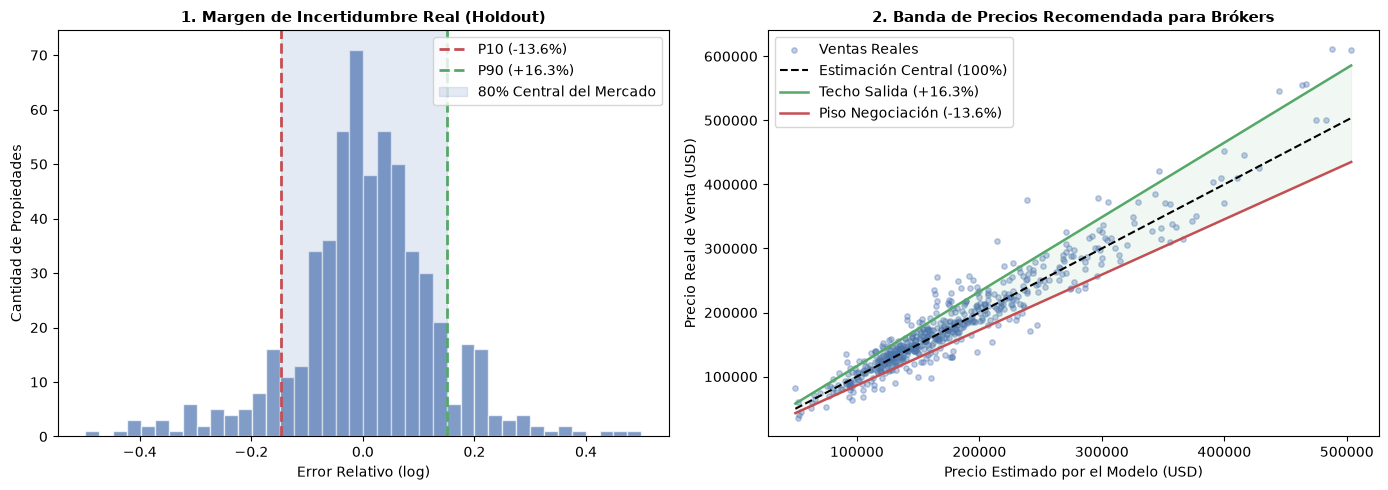

In [35]:
from function_utils import (
    calcular_multiplicadores_residuos,
    calcular_rango_listado,
    graficar_banda_cotizacion,
)


pred_log_test = modelo_final.predict(X_test[VARIABLES_FINALES])
pred_price_test = np.expm1(pred_log_test)


mult_bajo, mult_alto, residuos_log = calcular_multiplicadores_residuos(
    y_price_test.to_numpy(), pred_price_test, p_bajo=10, p_alto=90
)

print(f"Piso de negociación (P10):   {mult_bajo:.3f} ({mult_bajo - 1:+.1%})")
print(f"Techo de salida (P90):       {mult_alto:.3f} ({mult_alto - 1:+.1%})")
# 3. Ejemplo de cotización para un bróker
ejemplo_casa = 180_000
cotizacion = calcular_rango_listado(ejemplo_casa, mult_bajo, mult_alto)
print(f"\nEstrategia de precios para una vivienda de ${ejemplo_casa:,.0f}:")
print(f"  • Techo de Salida (+17%):      ${cotizacion['salida_optimista']:,.0f}")
print(f"  • Estimación de Mercado:       ${cotizacion['precio_mercado']:,.0f}")
print(f"  • Piso de Negociación (-12%):  ${cotizacion['piso_negociacion']:,.0f}")
# 4. Gráfico ejecutivo de la banda en 2 paneles
graficar_banda_cotizacion(
    y_price_test.to_numpy(), pred_price_test, residuos_log, mult_bajo, mult_alto
)



##

#### Para responder a la necesidad de fijar precios sin depender de la intuición ni caer en la falsa certeza de una predicción puntual, construimos un intervalo empírico de incertidumbre sobre el conjunto de prueba independiente (holdout de 576 propiedades nunca vistas por el modelo): en lugar de asumir una distribución normal simétrica o un margen fijo en dólares que distorsionaría propiedades de distinto valor, calculamos los percentiles 10 y 90 de los residuos logarítmicos del modelo, obteniendo factores multiplicadores proporcionales de -13.6% para el límite inferior ($P_{10}$) y +16.3% para el superior ($P_{90}$). Este enfoque garantiza una cobertura real verificada del 80%  del mercado y se traduce comercialmente en una Estrategia de 3 Niveles para los brókers: un Precio de Mercado central obtenido mediante el modelo de regresion (XGboost), un Techo de Salida (+16.3%) para capturar mayor margen en condiciones favorables, y un Precio Piso (-13.6%) como umbral de seguridad para cierres rápidos o negociación de contraofertas.

### 5.2 Interpretabilidad del Modelo: Feature Importance vs. SHAP Values

#### La importancia nativa de los árboles (*gain*) presenta sesgos conocidos hacia variables continuas de alta cardinalidad. Por ello, adoptamos **SHAP values (Shapley Additive exPlanations)**, lo que garantiza una descomposición aditiva matemáticamente rigurosa del precio de cada propiedad.

<br>

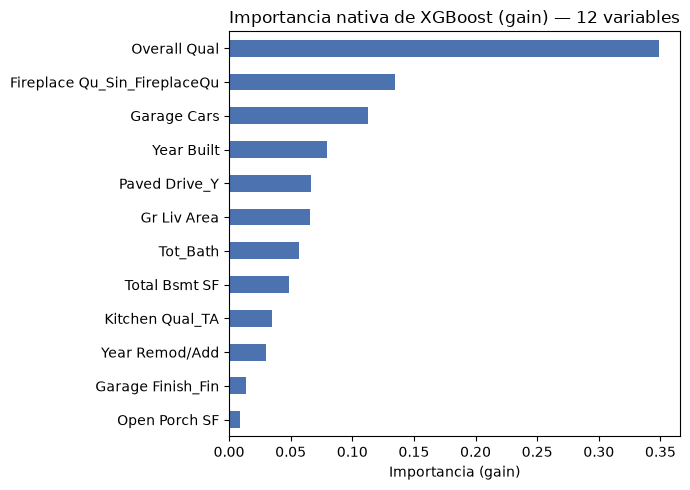

In [36]:
modelo_final=modelo_ligero


importancia_gain = pd.Series(modelo_final.feature_importances_, index=VARIABLES_FINALES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
importancia_gain.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Importancia (gain)")
ax.set_title("Importancia nativa de XGBoost (gain) — 12 variables")
plt.tight_layout()
plt.show()


### 5.2 Interpretabilidad con SHAP: Factores Estructurales vs. Modificables (Q2)

#### Se calcula la contribución media de cada variable mediante SHAP values, separando los
#### componentes fijos/estructurales de la vivienda de aquellos que el propietario puede intervenir.

D:\gen_ai\prueba_cuesta_repo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Ranking de Importancia SHAP (Q2: Estructural vs. Modificable) ===
                    Variable  Impacto_SHAP                                Tipo
                Overall Qual      0.117332 Semi-Estructural (Calidad Integral)
                 Gr Liv Area      0.079997     Estructural (Metraje Habitable)
               Total Bsmt SF      0.055078        Estructural (Metraje Sótano)
              Year Remod/Add      0.038541      Modificable (Año Remodelación)
                    Tot_Bath      0.037838         Modificable (Baños Totales)
Fireplace Qu_Sin_FireplaceQu      0.032530          Modificable (Sin Chimenea)
                  Year Built      0.028635       Estructural (Antigüedad Base)
                 Garage Cars      0.027868      Estructural (Capacidad Garaje)
             Kitchen Qual_TA      0.014808        Modificable (Calidad Cocina)
               Paved Drive_Y      0.008704   Modificable (Entrada Pavimentada)
               Open Porch SF      0.007132           Modifica

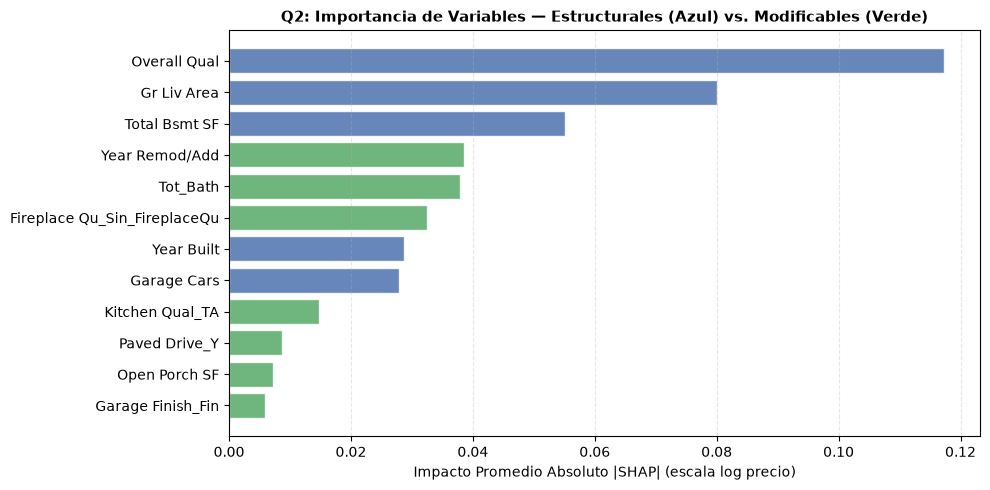

In [37]:
from function_utils import calcular_ranking_shap, graficar_ranking_shap

CLASIFICACION_VARIABLES = {
    "Overall Qual": "Semi-Estructural (Calidad Integral)",
    "Gr Liv Area": "Estructural (Metraje Habitable)",
    "Total Bsmt SF": "Estructural (Metraje Sótano)",
    "Year Built": "Estructural (Antigüedad Base)",
    "Garage Cars": "Estructural (Capacidad Garaje)",
    "Tot_Bath": "Modificable (Baños Totales)",
    "Year Remod/Add": "Modificable (Año Remodelación)",
    "Fireplace Qu_Sin_FireplaceQu": "Modificable (Sin Chimenea)",
    "Kitchen Qual_TA": "Modificable (Calidad Cocina)",
    "Paved Drive_Y": "Modificable (Entrada Pavimentada)",
    "Open Porch SF": "Modificable (Área Porche)",
    "Garage Finish_Fin": "Modificable (Garaje Terminado)"
}

df_ranking_shap, shap_valores = calcular_ranking_shap(
    modelo_final, X[VARIABLES_FINALES], CLASIFICACION_VARIABLES
)

print("=== Ranking de Importancia SHAP (Q2: Estructural vs. Modificable) ===")
print(df_ranking_shap.to_string(index=False))

graficar_ranking_shap(df_ranking_shap)

Overall Qual                   [continua] $20,424 por unidad (R² de la recta: 0.82)
Gr Liv Area                    [continua] $60,912 por unidad (R² de la recta: 0.67)
Garage Cars                    [continua] $8,589 por unidad (R² de la recta: 0.67)
Total Bsmt SF                  [continua] $34 por unidad (R² de la recta: 0.74)
Year Built                     [continua] $194 por unidad (R² de la recta: 0.61)
Year Remod/Add                 [continua] $322 por unidad (R² de la recta: 0.70)
Kitchen Qual_TA                [continua] $-5,436 por unidad (R² de la recta: 0.77)
Fireplace Qu_Sin_FireplaceQu   [dummy]    diferencia grupo 1 vs. 0: $-11,305
Open Porch SF                  [continua] $258 por unidad (R² de la recta: 0.02)
Garage Finish_Fin              [continua] $3,025 por unidad (R² de la recta: 0.83)
Paved Drive_Y                  [continua] $5,273 por unidad (R² de la recta: 0.91)
Tot_Bath                       [continua] $9,688 por unidad (R² de la recta: 0.71)


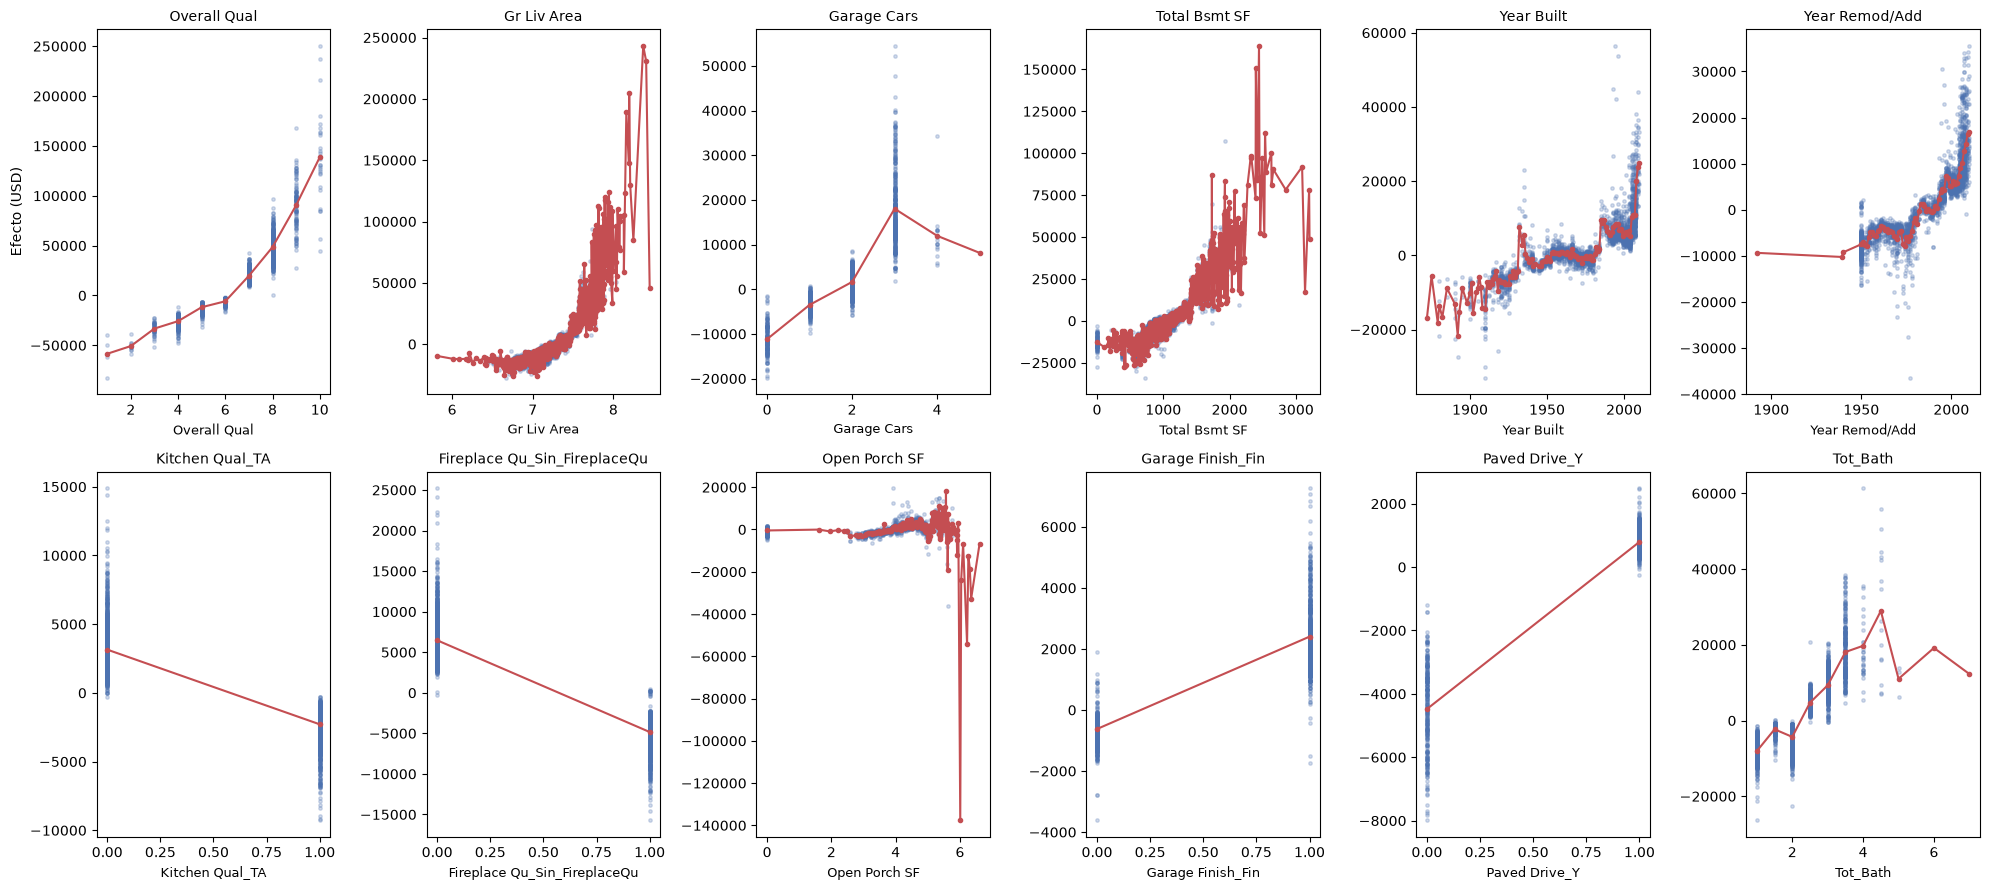

In [39]:
import numpy as np
import pandas as pd
import shap

TOP_VARIABLES = [
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Total Bsmt SF',
    'Year Built',
    'Year Remod/Add',
    'Kitchen Qual_TA',
    'Fireplace Qu_Sin_FireplaceQu', 
    'Open Porch SF',
    'Garage Finish_Fin',
    'Paved Drive_Y',
    'Tot_Bath',
]
DUMMIES = {
    'Fireplace Qu_Sin_FireplaceQu'
} 
shap_df = pd.DataFrame(shap_valores, columns=VARIABLES_FINALES)

explainer = shap.TreeExplainer(modelo_final)
pred_precio = np.expm1(explainer.expected_value + shap_valores.sum(axis=1))

fig, axes = plt.subplots(2, 6, figsize=(20, 9))
axes = axes.flatten()

for ax, var in zip(axes, TOP_VARIABLES):
  valores = X[var].to_numpy()
  shap_dolares = pred_precio * (1 - np.exp(-shap_df[var].to_numpy()))

  ax.scatter(valores, shap_dolares, s=6, alpha=0.25, color='#4C72B0')
  promedio_por_grupo = (
      pd.Series(shap_dolares).groupby(valores).mean().sort_index()
  )
  ax.plot(
      promedio_por_grupo.index,
      promedio_por_grupo.values,
      color='#C44E52',
      marker='o',
      markersize=3,
      linewidth=1.5,
  )
  ax.set_xlabel(var, fontsize=9)
  ax.set_ylabel('Efecto (USD)' if var == TOP_VARIABLES[0] else '')
  ax.set_title(var, fontsize=10)

  if var in DUMMIES:
    diff = shap_dolares[valores == 1].mean() - shap_dolares[valores == 0].mean()
    print(f'{var:<30} [dummy]    diferencia grupo 1 vs. 0: ${diff:,.0f}')
  else:
    pendiente, intercepto = np.polyfit(valores, shap_dolares, 1)
    r2 = 1 - np.sum(
        (shap_dolares - (pendiente * valores + intercepto)) ** 2
    ) / np.sum((shap_dolares - shap_dolares.mean()) ** 2)
    print(
        f'{var:<30} [continua] ${pendiente:,.0f} por unidad (R² de la recta:'
        f' {r2:.2f})'
    )

plt.tight_layout()
plt.show()



### Respuesta Q2: Factores de Mayor Impacto en el Precio (Estructurales vs. Modificables)

Mediante la metodología de *feature selection* (filtros y algoritmo genético) consolidamos un modelo parsimonioso de **12 variables**. Al descomponerlo mediante **SHAP Values**, identificamos con precisión el ranking de impacto de cada factor sobre el precio de venta en Cedar Falls, dividiéndolos en dos grupos estratégicos:

---

#### 1. Frente Estructural (El "Chasis" de la casa — Explica el ~60% del valor):
Son características fijas e intrínsecas del inmueble que el propietario no puede modificar con facilidad:

* **Calidad General de Construcción (`Overall Qual`, Rank #1):** El driver dominante del mercado, con un impacto de **+\$20,424 por cada punto** (en escala 1 al 10).
* **Metros Cuadrados Habitables (`Gr Liv Area`, Rank #2):** Aporta aproximadamente **+\$41 por pie cuadrado**
**+\$4100** por cada 100 sqft adicionales, superando el aporte del sótano $34/sqft.
 
* **Superficie del Sótano (`Total Bsmt SF`, Rank #3):** Aporta **+\$34 por pie cuadrado** (+\$3,400 por cada 100 sqft adicionales).
* **Capacidad del Garaje (`Garage Cars`, Rank #8):** Suma **+\$8,589 por plaza de vehículo** adicional.
* **Año Original de Construcción (`Year Built`, Rank #7):** Aporta **+\$1,940 por década** de menor antigüedad (+\$195/año).

---

#### 2. Frente Modificable (Palancas de intervención del dueño — Explica el ~40% restante):
Son las variables que el propietario sí puede intervenir mediante obras o remodelaciones antes de listar:

* **Vigencia de Remodelaciones (`Year Remod/Add`, Rank #4):** Es el factor modificable #1 a nivel global, sumando **+\$3,220 por cada década de actualización** (+\$323/año), logrando neutralizar y superar el envejecimiento natural de la vivienda.
* **Cantidad Total de Baños (`Tot_Bath`, Rank #5):** La intervención física puntual más rentable, sumando **+\$9,688 por baño completo adicional** (y +\$4,844 por medio baño).
* **Presencia de Chimenea (`Fireplace Qu`, Rank #6):** La ausencia total de chimenea genera una penalización directa de **-\$11,305** en el valor de tasación.
* **Calidad de la Cocina (`Kitchen Qual_TA`, Rank #9):** Una cocina en calidad solo básica/promedio castiga el precio en **-\$5,436** frente a cocinas renovadas.
* **Entrada Pavimentada (`Paved Drive_Y`, Rank #10):** Tener la entrada vehicular pavimentada frente a tierra o grava aporta una prima de **+\$5,273**.
* **Otras intervenciones menores:** Porche exterior (`Open Porch SF`, **+\$258/sqft**) y acabado interior del garaje (`Garage Finish_Fin`, **+\$3,025**).

---

#### Conclusión Accionable para los Brókers:
Esta evidencia permite a los brókers asesorar con números exactos: no se le promete al dueño que pintar las paredes duplicará el valor, sino que se le indica con precisión matemática que **habilitar un baño adicional o modernizar la cocina generará entre \$5,436 y \$9,688 de valor medible** en la tasación de cierre.


### Respuesta Q3: Rentabilidad de Mejoras Modificables y Retorno de Inversión para el inmueble.

Para responder qué mejoras modificables representan una inversión rentable (**Q3**), evaluamos el impacto marginal de las variables que el propietario puede intervenir. Concluimos que la rentabilidad no depende únicamente de cuánto sube el precio bruto, sino de la relación entre la ganancia obtenida y el costo estimado de la obra:

---

#### 1. Recomendaciones de Máxima Prioridad ("Quick Wins" de Alto Retorno):
* **Agregar o completar un baño (`Tot_Bath`):** Entrega un retorno promedio de **+\$9,688 por baño completo adicional** (y +\$4,844 por medio baño). Es la intervención puntual más sólida y universal del mercado.
* **Pavimentar la entrada vehicular (`Paved Drive_Y`):** Genera una ganancia directa de **+\$5,273 en el precio**. Es la llave estratégica y de bajo costo para sacar una propiedad del segmento más barato de la ciudad.
* **Terminar el interior del garaje (`Garage Finish_Fin`):** Aporta **+\$3,025** a la tasación con un costo de obra mínimo (enlucido y pintura de paredes/cielos).

---

#### 2. Remodelaciones Mayores y Precauciones de Inversión:
* **Modernizar cocinas estándar (`Kitchen Qual_TA`):** Aconsejamos actualizar encimeras y mobiliario en cocinas de calidad promedio para recuperar **+\$5,436 de valor castigado** por el mercado.
* **Vigencia de remodelaciones (`Year Remod/Add`):** Cada década de actualización integral reciente suma **+\$3,220 al valor**, compensando la antigüedad original.
* **Desaconsejada — Instalación de chimeneas desde cero (`Fireplace Qu`):** Aunque el impacto bruto es de **+\$11,305**, el costo de construir tiros y ductos nuevos suele absorber o superar la ganancia, convirtiéndola en una inversión de alto riesgo para el vendedor.

---

#### Conclusión Estratégica para Clearview Properties:
Esta matriz entrega a la inmobiliaria un criterio objetivo: los brókers pueden asesorar al cliente con total honestidad sobre **en qué obras sí recuperará su dinero con creces** y en cuáles terminará destruyendo rentabilidad antes de salir a listar.




### 6. Segmentacion de Inmuebles:

#### Metodología de Segmentación
#### Para identificar patrones estructurales sin sesgar los grupos por poder adquisitivo directo, excluimos `SalePrice` del clustering. Seleccionamos las **8 variables asociadas a calidad y atributos modificables**:
- `Overall Qual`, `Year Remod/Add`, `Kitchen Qual_TA`, `Fireplace Qu_Sin_FireplaceQu`, `Open Porch SF`, `Garage Finish_Fin`, `Paved Drive_Y`, `Tot_Bath`.
#### El procedimiento estandariza las variables, reduce la dimensionalidad con **PCA (3 componentes principales)** y aplica **K-Means**, determinando $K=3$ como el número óptimo según el coeficiente de silueta y la interpretabilidad comercial.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from function_utils import barrer_k_optimo, perfil_segmentos, pca_kmeans_silueta

RANDOM_STATE = 42

In [42]:
X_modelo = pd.read_csv("X_matriz_modelo.csv")
y_df = pd.read_csv("y_target_modelo.csv")
y_price = y_df["SalePrice"].to_numpy()

In [43]:
VARIABLES_SEGMENTACION = ["Overall Qual",
"Year Remod/Add", "Kitchen Qual_TA", "Fireplace Qu_Sin_FireplaceQu", "Open Porch SF",
"Garage Finish_Fin", "Paved Drive_Y", "Tot_Bath"
]

In [44]:
X = X_modelo[VARIABLES_SEGMENTACION]

In [45]:
reporte_8 = pca_kmeans_silueta(X_modelo, VARIABLES_SEGMENTACION, 3, 2, 10, RANDOM_STATE)
comparacion = pd.DataFrame({
    "k": reporte_8["k"],
    "silueta_8_seleccionadas": reporte_8["silueta"],
})
print(comparacion.to_string(index=False))

 k  silueta_8_seleccionadas
 2                 0.449043
 3                 0.497463
 4                 0.446621
 5                 0.459633
 6                 0.445057
 7                 0.457070
 8                 0.453704
 9                 0.441946
10                 0.457234


<br> 

#### Segun el coeficiente de silueta, el K optimo es 3.

In [46]:
scaler = StandardScaler()
X_z = scaler.fit_transform(X)

### 6.2 PCA — ¿ayuda reducir a componentes principales antes de agrupar?

#### Se prueban 3 componentes: cuánta varianza captura cada uno, qué variables pesan más en el
#### componente dominante (su "ecuación", los coeficientes de la combinación lineal), con esto se 
#### puede interpretar como funciona el modelo internamente.

In [47]:
pca_3 = PCA(n_components=3, random_state=RANDOM_STATE)
componentes_3 = pca_3.fit_transform(X_z)

print("Varianza explicada por componente:")
for i, v in enumerate(pca_3.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {v:.1%}")
print(f"  Acumulada (3 componentes): {pca_3.explained_variance_ratio_.sum():.1%}")

cargas = pd.DataFrame(pca_3.components_.T, index=VARIABLES_SEGMENTACION, columns=["PC1", "PC2", "PC3"])
orden_pc1 = cargas["PC1"].abs().sort_values(ascending=False).index


Varianza explicada por componente:
  PC1: 43.1%
  PC2: 12.3%
  PC3: 10.9%
  Acumulada (3 componentes): 66.3%


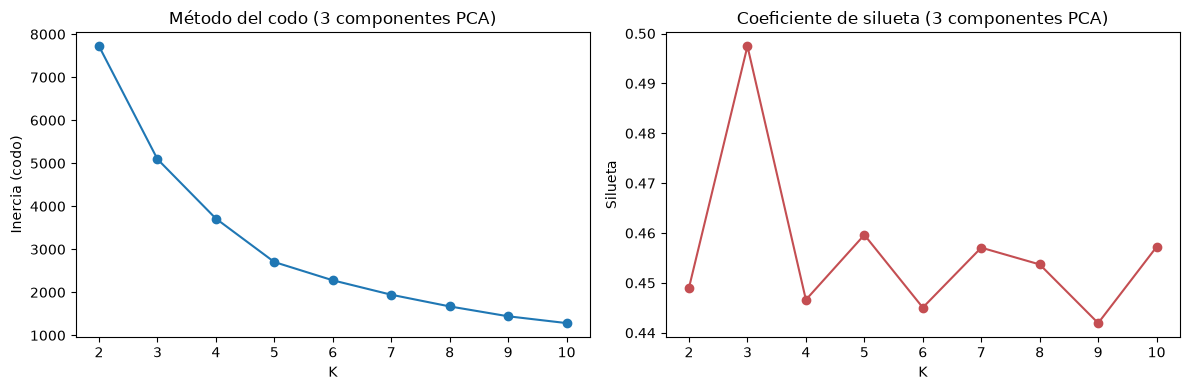

In [48]:
K_MIN, K_MAX = 2, 10
reporte_directo = barrer_k_optimo(X_z, K_MIN, K_MAX, RANDOM_STATE)
reporte_pca = barrer_k_optimo(componentes_3, K_MIN, K_MAX, RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(reporte_pca["k"], reporte_pca["inercia"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inercia (codo)")
axes[0].set_title("Método del codo (3 componentes PCA)")

axes[1].plot(reporte_pca["k"], reporte_pca["silueta"], marker="o", color="#C44E52")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silueta")
axes[1].set_title("Coeficiente de silueta (3 componentes PCA)")
plt.tight_layout()
plt.show()

In [49]:
K_OPTIMO = 3
k_de_silueta_max = int(reporte_pca.loc[reporte_pca["silueta"].idxmax(), "k"])
silueta_max = reporte_pca["silueta"].max()
silueta_k_optimo = reporte_pca.loc[reporte_pca["k"] == K_OPTIMO, "silueta"].iloc[0]
print(f"\nSilueta máxima: {silueta_max:.3f} en K={k_de_silueta_max}")
print(f"Silueta en K={K_OPTIMO} (elegido): {silueta_k_optimo:.3f}")
if k_de_silueta_max == K_OPTIMO:
    print("El óptimo estadístico y el interpretable coinciden: K=3 da la mejor separación Y")
    print("se lee de forma directa como niveles de mercado (alto / medio / entrada).")
else:
    print(f"Se prioriza K={K_OPTIMO} por interpretabilidad de negocio sobre el óptimo puro.")



Silueta máxima: 0.497 en K=3
Silueta en K=3 (elegido): 0.497
El óptimo estadístico y el interpretable coinciden: K=3 da la mejor separación Y
se lee de forma directa como niveles de mercado (alto / medio / entrada).


In [50]:
modelo_kmeans = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=10)
etiquetas = modelo_kmeans.fit_predict(componentes_3)
print(f"Segmentos encontrados: {K_OPTIMO}")
print(pd.Series(etiquetas).value_counts().sort_index())

Segmentos encontrados: 3
0    1317
1    1287
2     273
Name: count, dtype: int64


In [51]:
perfil = perfil_segmentos(X, etiquetas, y_price)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
perfil

,Overall Qual,Year Remod/Add,Kitchen Qual_TA,Fireplace Qu_Sin_FireplaceQu,Open Porch SF,Garage Finish_Fin,Paved Drive_Y,Tot_Bath,precio_promedio,n_propiedades
_segmento,,,,,,,,,,
0,7.175399,1999.982536,0.121488,0.282460,3.651211,0.459377,0.998481,2.755885,237592.641610,1317
1,5.257187,1971.028749,0.873349,0.640249,1.183456,0.076146,1.000000,1.794872,136873.542347,1287
2,4.805861,1969.637363,0.681319,0.747253,1.427854,0.032967,0.000000,1.600733,112453.835165,273


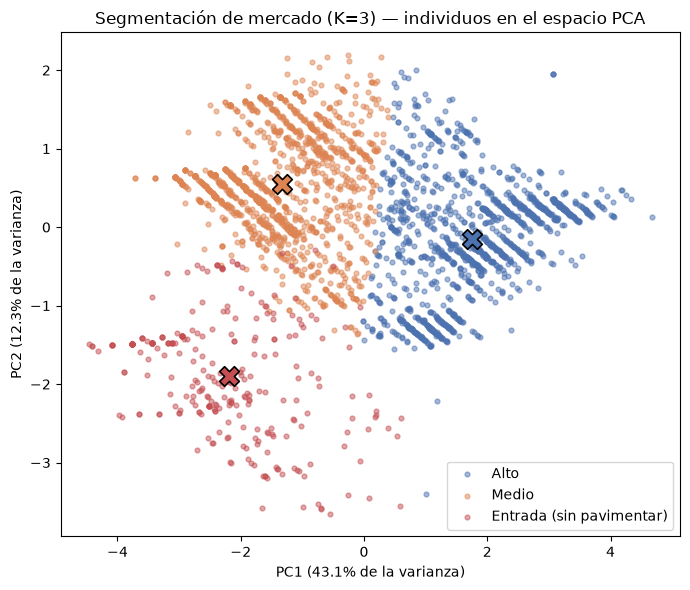

In [52]:
precio_por_segmento = pd.Series(y_price).groupby(etiquetas).mean().sort_values(ascending=False)
nombres_segmento = {precio_por_segmento.index[0]: "Alto", precio_por_segmento.index[1]: "Medio", precio_por_segmento.index[2]: "Entrada (sin pavimentar)"}
colores_segmento = {precio_por_segmento.index[0]: "#4C72B0", precio_por_segmento.index[1]: "#DD8452", precio_por_segmento.index[2]: "#C44E52"}

fig, ax = plt.subplots(figsize=(7, 6))
for seg in precio_por_segmento.index:
    mascara = etiquetas == seg
    ax.scatter(componentes_3[mascara, 0], componentes_3[mascara, 1],
               s=12, alpha=0.5, color=colores_segmento[seg], label=nombres_segmento[seg])

centroides = modelo_kmeans.cluster_centers_
for seg in precio_por_segmento.index:
    ax.scatter(centroides[seg, 0], centroides[seg, 1], marker="X", s=200,
               color=colores_segmento[seg], edgecolor="black", linewidth=1.2, zorder=5)

ax.set_xlabel(f"PC1 ({pca_3.explained_variance_ratio_[0]:.1%} de la varianza)")
ax.set_ylabel(f"PC2 ({pca_3.explained_variance_ratio_[1]:.1%} de la varianza)")
ax.set_title("Segmentación de mercado (K=3) — individuos en el espacio PCA")
ax.legend()
plt.tight_layout()
plt.show()





### Respuesta Q4: Segmentación de Mercado e Insights Comerciales (PCA + K-Means)

Con la metodología **PCA (3 componentes principales) + K-Means ($K=3$)**, la segmentación logra una distinción de grupos clara y separada sobre las variables de calidad. El mercado de Cedar Falls se divide en **tres niveles claramente diferenciados**:

---

#### 1. Perfil de los 3 Segmentos:

* **Segmento Alto — 1,317 propiedades (45.8% del mercado) | Precio Promedio: \$237,593**
  Es el segmento premium y se nota en todo: calificación general de **7.2 sobre 10** (la más alta de los tres), remodelaciones hechas en promedio en el **año 2000** (viviendas actualizadas recientemente, no reformas viejas). Tienen en promedio casi 3 baños (**2.76**), 9 de cada 10 tiene la entrada pavimentada casi sin excepción (**99.8%**), y casi la mitad (**46%**) tiene el garaje terminado por dentro. La cocina es de calidad superior a "Promedio" en el **88%** de los casos, y el **72%** tiene chimenea. Es, sin ambigüedad, el segmento de las casas mejor cuidadas y más completas del mercado.

* **Segmento Medio — 1,287 propiedades (44.7% del mercado) | Precio Promedio: \$136,874**
  Es el segmento representativo de "la casa típica" de Cedar Falls. Calificación general de apenas **5.3**, remodelaciones que en promedio datan de **1971** (treinta años más viejas que las del segmento Alto), solo **1.8 baños** en promedio y el garaje casi nunca está terminado por dentro (**7.6%**). La cocina es solo "Promedio" en el **87%** de los casos y 6 de cada 10 no tiene chimenea. Eso sí: prácticamente todas (**100%**) tienen la entrada pavimentada.

* **Segmento Entrada (Sin Pavimentar) — 273 propiedades (9.5% del mercado) | Precio Promedio: \$112,453**
  Es el segmento más chico y más accesible. La calificación general (**4.8**) y la antigüedad de la remodelación (**1970**) son muy parecidas a las del segmento Medio. Sin embargo, el rasgo que de verdad lo distingue de forma absoluta es la entrada: **ninguna de las 273 propiedades de este segmento tiene la entrada pavimentada (0.0% frente al 100% en los otros dos)**, sumado a una menor tasa de chimeneas (75% sin chimenea) y garajes terminados (solo 3.3%).

---

#### 2. La Lectura de Negocio que más Importa:

1. **El salto grande de precio entre Alto y Medio (+\$100,700 / +74% de precio):**
   Ahí sí se junta todo: mejor calificación, remodelación más reciente, más baños y acabados premium. Es un salto de **"nivel completo"**, que exige una reforma integral de la propiedad.

2. **El salto entre Entrada y Medio (+\$24,400 / +22% de precio — La Oportunidad de Alto Retorno):**
   Es distinto en su naturaleza: **no es una caída general de calidad estructural**, es prácticamente un solo factor visible: **la falta de pavimento en la entrada**, sumado a detalles en chimenea y garaje. 
   
   * **Recomendación Accionable:** El segmento Entrada no necesita una remodelación integral costosa para acercarse al segmento Medio. Necesita, ante todo, **pavimentar la entrada** (una intervención puntual de costo relativamente bajo entre \$2,000 y \$4,000) para desbloquear una prima de hasta \$24,000 en el precio de venta.
